# Disease Risk Prediction (Diabetes)


## Project Background

Diabetes is a chronic metabolic disorder affecting millions worldwide. Early identification
of high-risk individuals enables timely preventive care and reduces long-term complications.
This project builds classification models to predict whether a patient is diabetic based
on clinical measurements.

**Dataset:** Pima Indians Diabetes Database (diabetes.csv)
**Source:** National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) / UCI ML Repository
**Rows:** 768 patients (all female, age 21+, Pima Indian heritage)
**Columns:** 8 clinical features + 1 target
**Target variable:** Outcome (1 = diabetic, 0 = non-diabetic)

**Features:**
- Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age

**CDL Learning Outcomes covered:**
- LO1: Build and evaluate ML models for classification tasks
- LO2: Data preprocessing, EDA and feature engineering
- LO3: Python programming with data science libraries
- LO4: Model evaluation, comparison and optimisation
- LO6: Problem-solving for complex data challenges (invalid zero values)
- LO8: Analytical thinking in data analysis and decision making

---

## Table of Contents
1. Import Libraries
2. Load and Inspect the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing (Handling Invalid Zeros)
5. Feature Engineering
6. Train / Test Split
7. Model Building
   - 7.1 Logistic Regression
   - 7.2 Decision Tree Classifier
   - 7.3 Random Forest Classifier
8. Hyperparameter Tuning (Grid Search)
9. Model Evaluation and Comparison
10. Feature Importance Analysis
11. Conclusions and Clinical Recommendations


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Load and Inspect the Dataset

In [2]:
df = pd.read_csv("diabetes.csv")

print("Dataset shape:", df.shape)
print()
df.head()


Dataset shape: (768, 9)



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
print("=== Descriptive Statistics ===")
df.describe().round(2)


=== Descriptive Statistics ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


=== Class Distribution ===
  Non-Diabetic (0): 500 patients (65.1%)
  Diabetic     (1): 268 patients (34.9%)


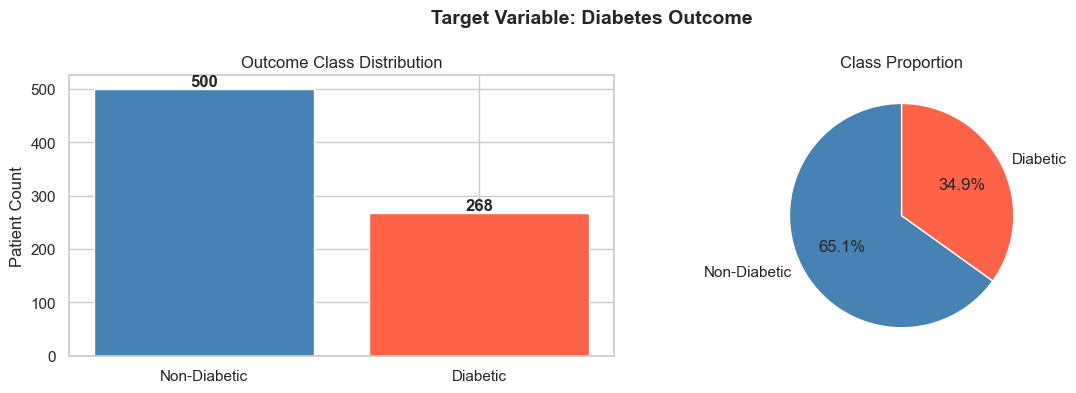

In [5]:
# Check target class distribution
outcome_counts = df["Outcome"].value_counts()
outcome_pct    = df["Outcome"].value_counts(normalize=True) * 100

print("=== Class Distribution ===")
print(f"  Non-Diabetic (0): {outcome_counts[0]} patients ({outcome_pct[0]:.1f}%)")
print(f"  Diabetic     (1): {outcome_counts[1]} patients ({outcome_pct[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(["Non-Diabetic", "Diabetic"],
            outcome_counts.values, color=["steelblue", "tomato"])
axes[0].set_title("Outcome Class Distribution")
axes[0].set_ylabel("Patient Count")
for i, v in enumerate(outcome_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

axes[1].pie(
    outcome_counts.values,
    labels=["Non-Diabetic", "Diabetic"],
    autopct="%1.1f%%",
    colors=["steelblue", "tomato"],
    startangle=90
)
axes[1].set_title("Class Proportion")

plt.suptitle("Target Variable: Diabetes Outcome", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Exploratory Data Analysis (EDA)

In [6]:
# Detect zero values in columns where 0 is physiologically impossible
# Zero Glucose, BloodPressure, BMI, SkinThickness, Insulin = missing data
zero_invalid_cols = ["Glucose", "BloodPressure", "BMI", "SkinThickness", "Insulin"]

print("=== Zero Value Count (these represent missing data) ===")
for col in zero_invalid_cols:
    count = (df[col] == 0).sum()
    pct   = count / len(df) * 100
    print(f"  {col:30s}: {count} zeros ({pct:.1f}%)")


=== Zero Value Count (these represent missing data) ===
  Glucose                       : 5 zeros (0.7%)
  BloodPressure                 : 35 zeros (4.6%)
  BMI                           : 11 zeros (1.4%)
  SkinThickness                 : 227 zeros (29.6%)
  Insulin                       : 374 zeros (48.7%)


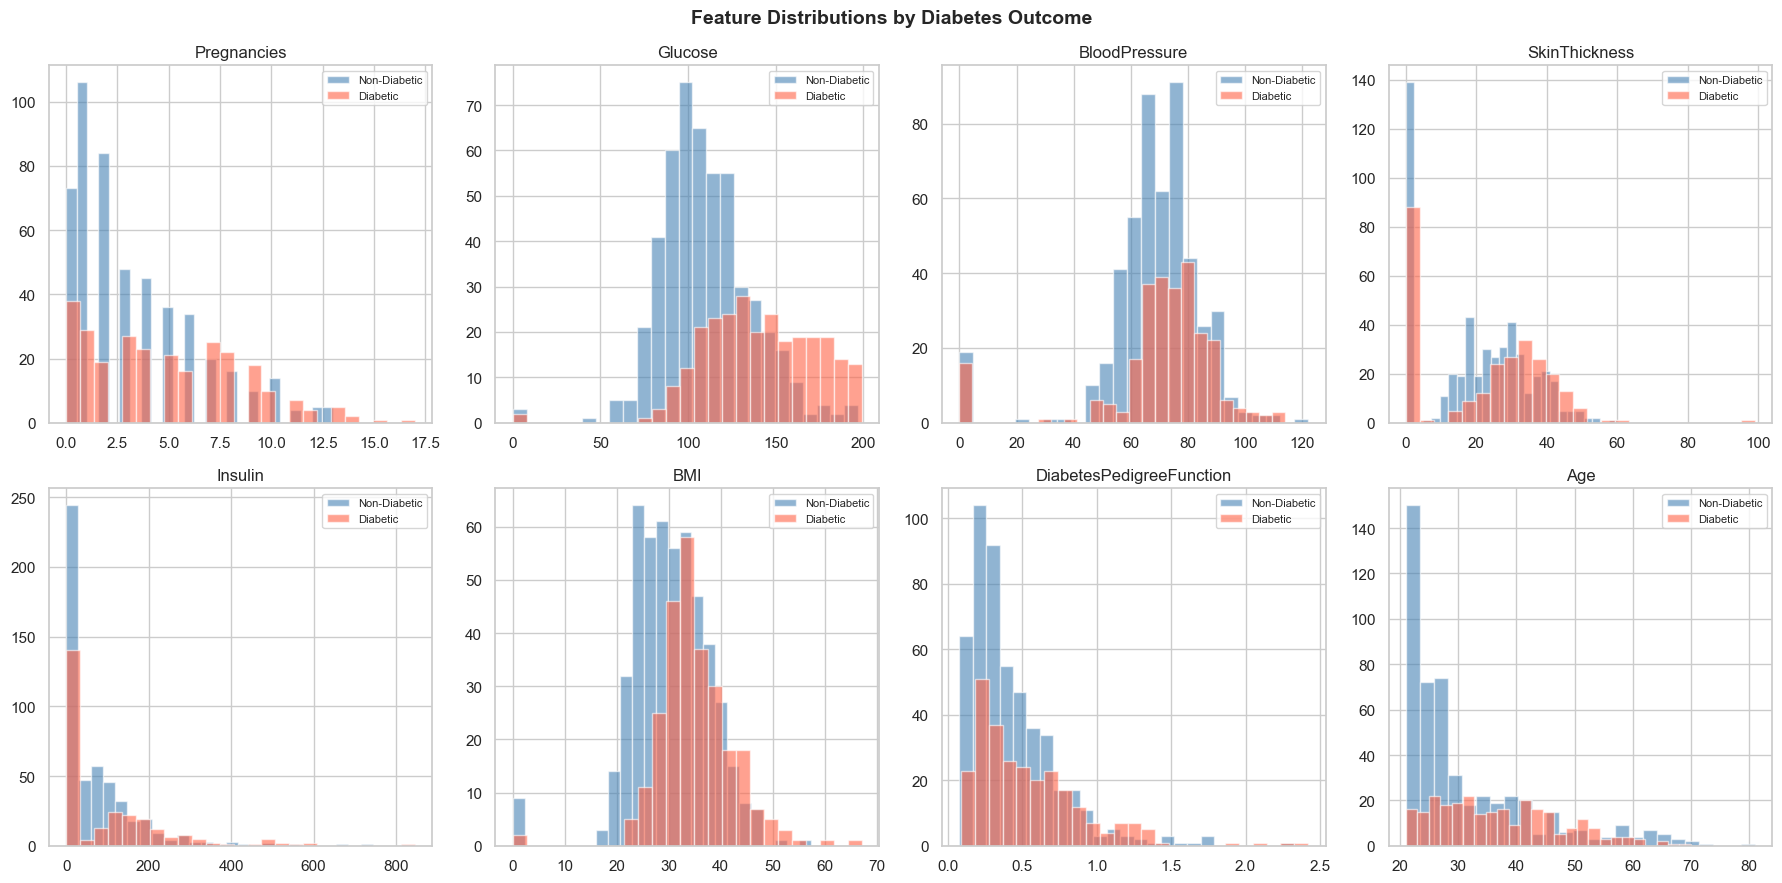

In [7]:
# Feature distributions split by outcome class
numeric_features = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, feat in enumerate(numeric_features):
    axes[idx].hist(
        df[df["Outcome"] == 0][feat],
        bins=25, alpha=0.6, color="steelblue", label="Non-Diabetic"
    )
    axes[idx].hist(
        df[df["Outcome"] == 1][feat],
        bins=25, alpha=0.6, color="tomato", label="Diabetic"
    )
    axes[idx].set_title(feat)
    axes[idx].legend(fontsize=8)

plt.suptitle("Feature Distributions by Diabetes Outcome",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


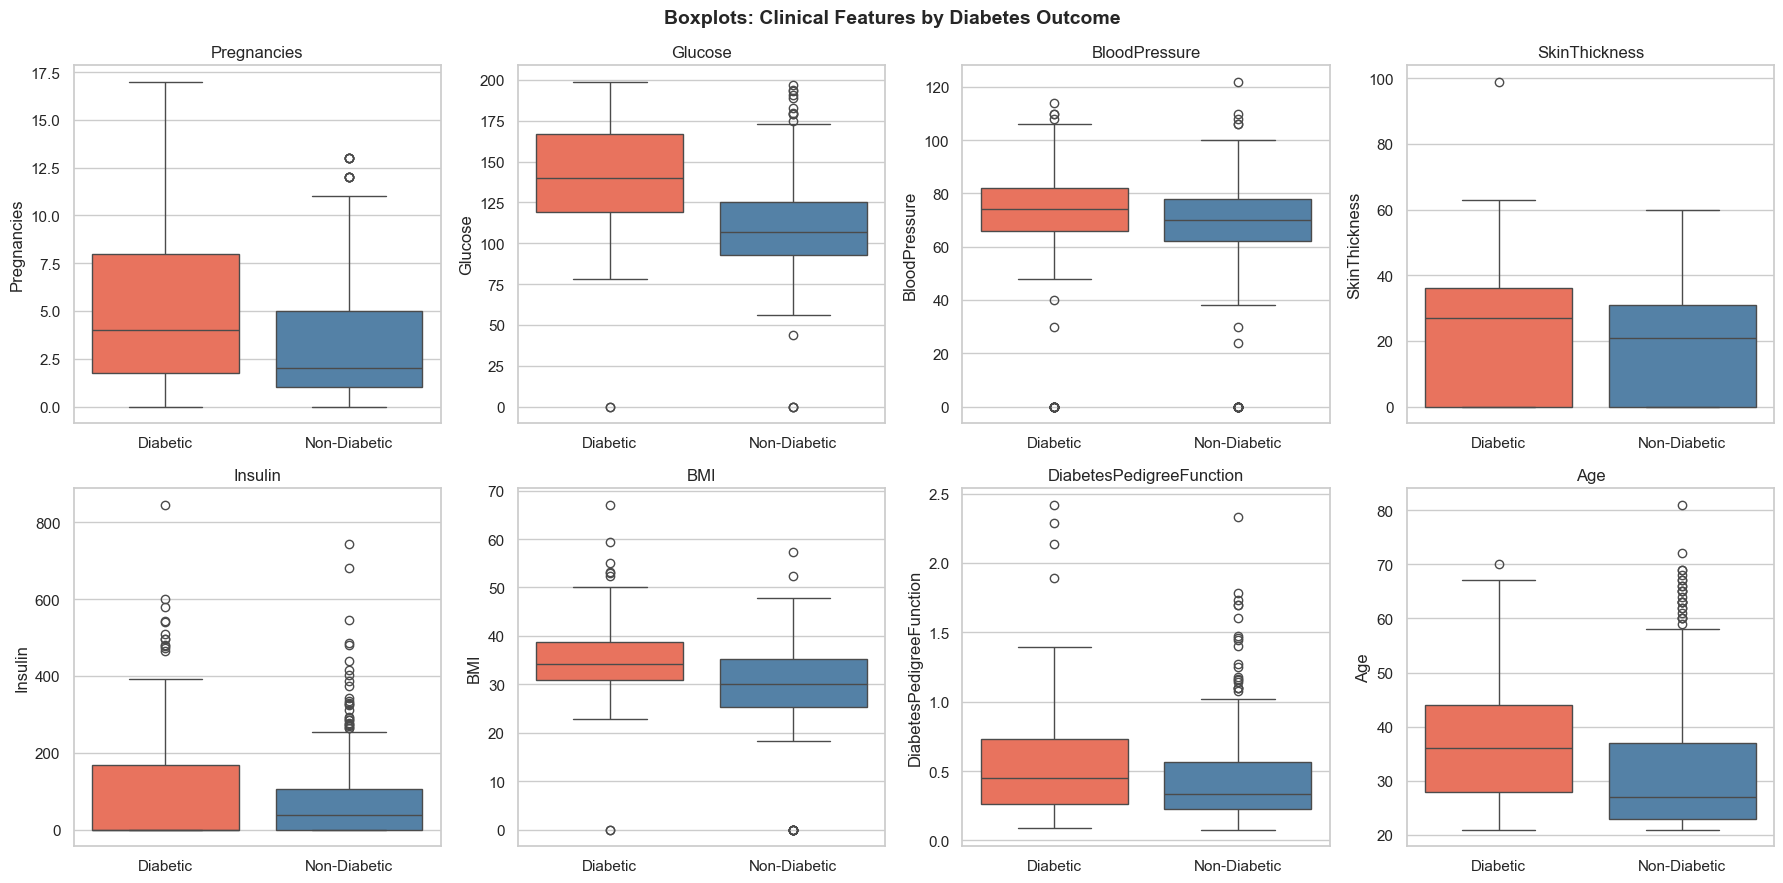

In [8]:
# Boxplots for key clinical features
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
df_plot = df.copy()
df_plot["Status"] = df_plot["Outcome"].map({0: "Non-Diabetic", 1: "Diabetic"})
palette = {"Non-Diabetic": "steelblue", "Diabetic": "tomato"}

for idx, feat in enumerate(numeric_features):
    sns.boxplot(data=df_plot, x="Status", y=feat, palette=palette, ax=axes[idx])
    axes[idx].set_title(feat)
    axes[idx].set_xlabel("")

plt.suptitle("Boxplots: Clinical Features by Diabetes Outcome",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


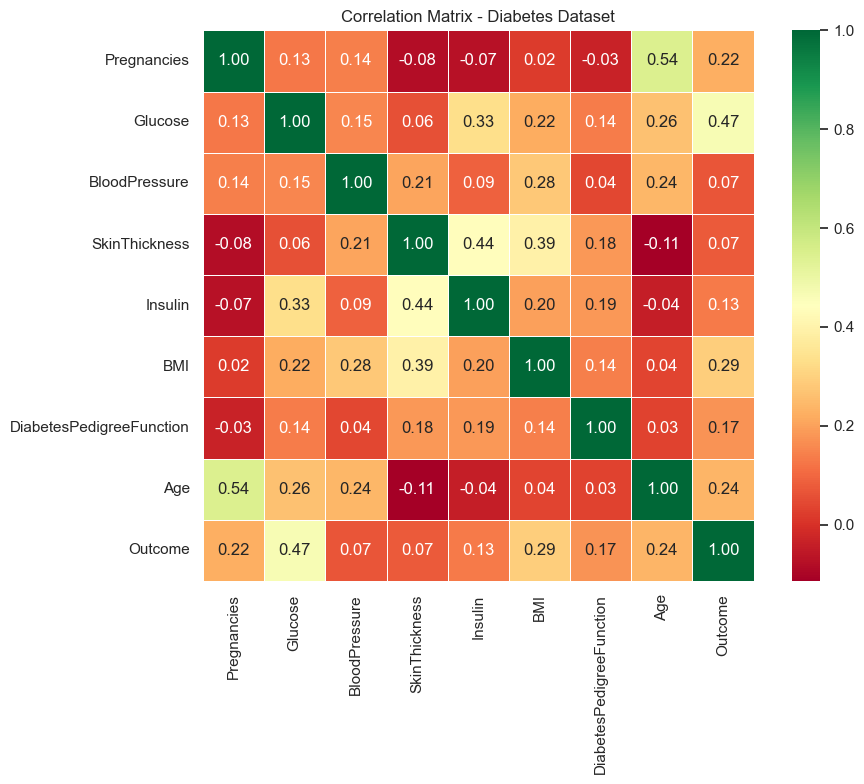

Insight: Glucose has the highest positive correlation with Outcome (diabetes).


In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True, fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5,
    square=True
)
plt.title("Correlation Matrix - Diabetes Dataset")
plt.tight_layout()
plt.show()

print("Insight: Glucose has the highest positive correlation with Outcome (diabetes).")


## 4. Data Preprocessing (Handling Invalid Zeros)

In this dataset, zero values in Glucose, BloodPressure, BMI, SkinThickness, and
Insulin are not physiologically valid. They represent missing or unrecorded values.
We replace them with NaN and then impute using the column median.


In [9]:
df_clean = df.copy()

# Replace zero values with NaN in columns where 0 is medically invalid
zero_invalid_cols = ["Glucose", "BloodPressure", "BMI", "SkinThickness", "Insulin"]
for col in zero_invalid_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("Missing values after replacing invalid zeros:")
print(df_clean.isnull().sum())


Missing values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [10]:
# Impute missing values with the column median
# Median is robust to the skewed distributions present in clinical data
imputer = SimpleImputer(strategy="median")
df_clean[zero_invalid_cols] = imputer.fit_transform(df_clean[zero_invalid_cols])

print("Missing values after median imputation:", df_clean.isnull().sum().sum())
print()
print("Updated descriptive statistics:")
df_clean.describe().round(2)


Missing values after median imputation: 0

Updated descriptive statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.66,72.39,29.11,140.67,32.46,0.47,33.24,0.35
std,3.37,30.44,12.10,8.79,86.38,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,121.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


## 5. Feature Engineering

In [11]:
#  BMI Risk Category 
# Based on standard WHO BMI classification
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25.0:
        return "Normal"
    elif bmi < 30.0:
        return "Overweight"
    else:
        return "Obese"

df_clean["BMI_Category"] = df_clean["BMI"].apply(bmi_category)

# Age Group 
df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=[20, 30, 45, 60, 100],
    labels=["21_30", "31_45", "46_60", "61plus"]
)

# --- High Glucose Flag: clinical threshold for hyperglycaemia ---
df_clean["High_Glucose"] = (df_clean["Glucose"] > 140).astype(int)

# --- Interaction term: BMI x Glucose ---
# Patients with both high BMI and high Glucose carry compounded risk
df_clean["BMI_Glucose_Interaction"] = (
    df_clean["BMI"] * df_clean["Glucose"] / 1000
)

# One-hot encode the new categorical features
df_encoded = pd.get_dummies(
    df_clean,
    columns=["BMI_Category", "Age_Group"],
    drop_first=True
)

print("Shape after feature engineering:", df_encoded.shape)
print("Features added: BMI_Category, Age_Group, High_Glucose, BMI_Glucose_Interaction")


Shape after feature engineering: (768, 17)
Features added: BMI_Category, Age_Group, High_Glucose, BMI_Glucose_Interaction


## 6. Train / Test Split

In [12]:
X = df_encoded.drop(columns=["Outcome"]).copy()
y = df_encoded["Outcome"]

# Standardise numeric features
scaler = StandardScaler()
scale_cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age",
    "BMI_Glucose_Interaction"
]
X[scale_cols] = scaler.fit_transform(X[scale_cols])

# Stratified 80/20 split preserves class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"Train diabetic rate : {y_train.mean() * 100:.1f}%")
print(f"Test  diabetic rate : {y_test.mean() * 100:.1f}%")


Training samples : 614
Testing  samples : 154
Train diabetic rate : 34.9%
Test  diabetic rate : 35.1%


## 7. Model Building

### 7.1 Logistic Regression

Logistic Regression is a probabilistic linear classifier well-suited for clinical
datasets. Its coefficients are directly interpretable as log-odds of the outcome.


In [13]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr.fit(X_train, y_train)
lr_pred  = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression training complete.")
print(f"  Accuracy : {accuracy_score(y_test, lr_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, lr_pred):.4f}")
print(f"  F1 Score : {f1_score(y_test, lr_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, lr_proba):.4f}")


Logistic Regression training complete.
  Accuracy : 0.7597
  Recall   : 0.7593
  F1 Score : 0.6891
  ROC-AUC  : 0.8361


### 7.2 Decision Tree Classifier

Decision Trees produce human-readable rules. max_depth=5 prevents overfitting
on the 614-sample training set.


Decision Tree training complete.
  Accuracy : 0.7468
  Recall   : 0.7407
  F1 Score : 0.6723
  ROC-AUC  : 0.7705


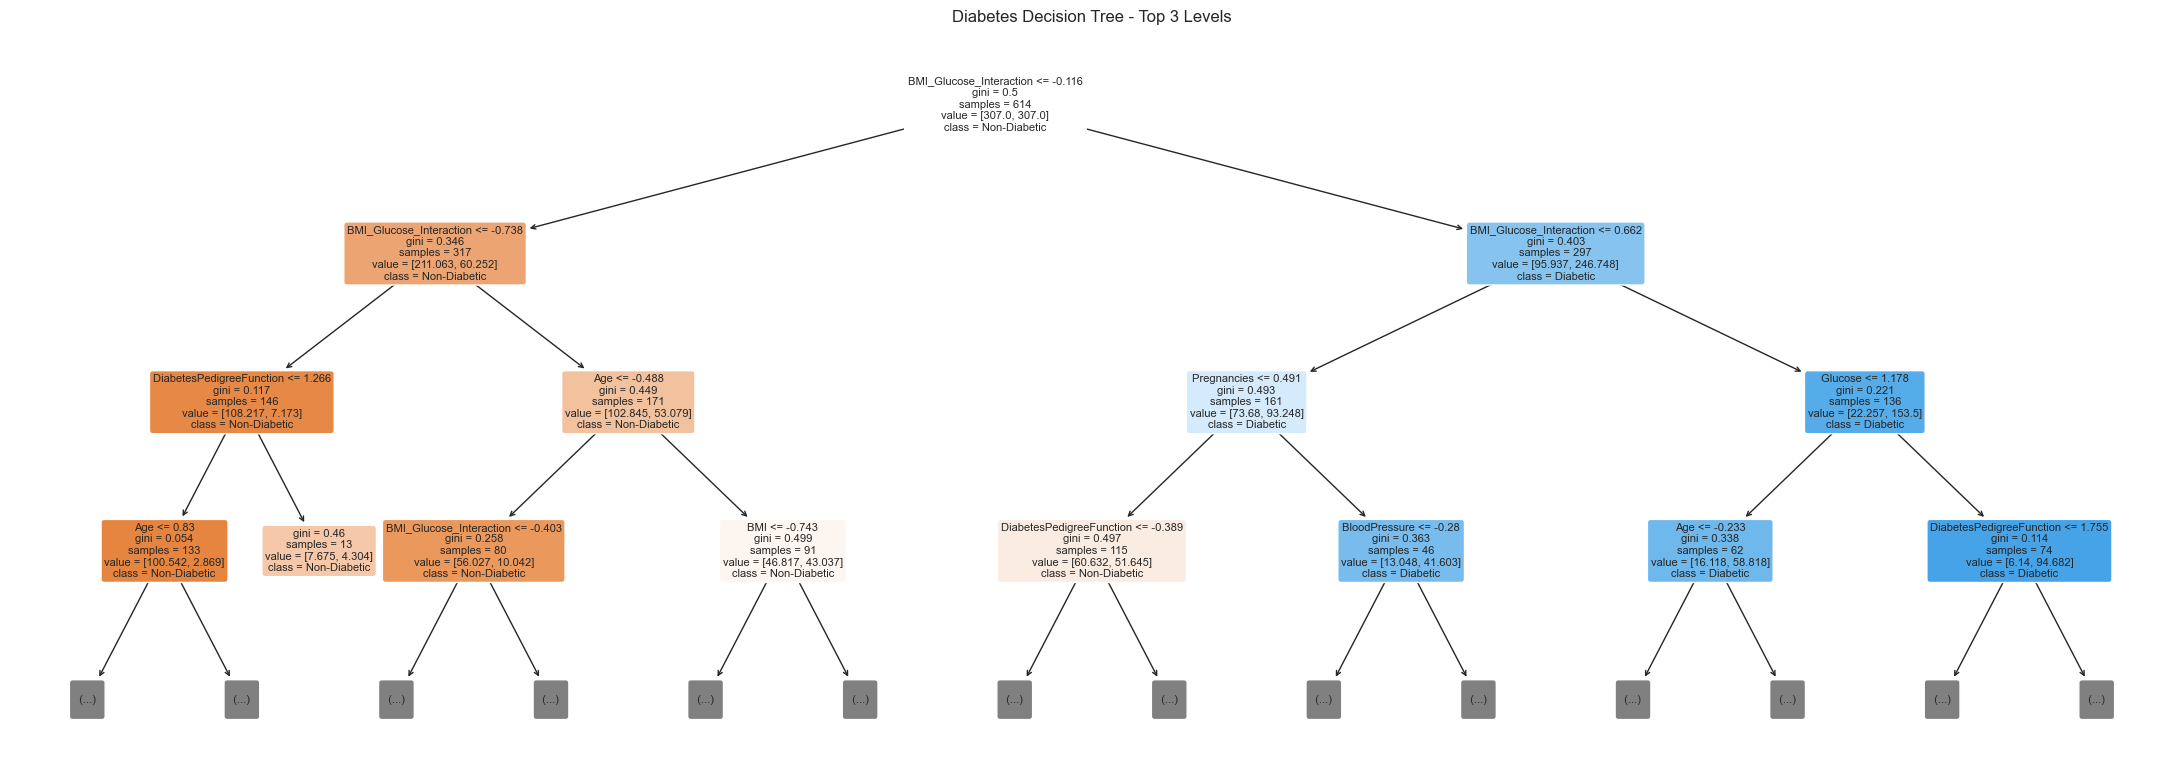

In [14]:
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)
dt.fit(X_train, y_train)
dt_pred  = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

print("Decision Tree training complete.")
print(f"  Accuracy : {accuracy_score(y_test, dt_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, dt_pred):.4f}")
print(f"  F1 Score : {f1_score(y_test, dt_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, dt_proba):.4f}")

plt.figure(figsize=(22, 8))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=["Non-Diabetic", "Diabetic"],
    filled=True,
    max_depth=3,
    fontsize=8,
    rounded=True
)
plt.title("Diabetes Decision Tree - Top 3 Levels")
plt.tight_layout()
plt.show()


### 7.3 Random Forest Classifier

Random Forest reduces variance through ensemble averaging. It typically achieves
higher generalisation accuracy than a single Decision Tree.


In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Random Forest training complete.")
print(f"  Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, rf_pred):.4f}")
print(f"  F1 Score : {f1_score(y_test, rf_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}")


Random Forest training complete.
  Accuracy : 0.7208
  Recall   : 0.5926
  F1 Score : 0.5981
  ROC-AUC  : 0.8233


## 8. Hyperparameter Tuning (Grid Search - Random Forest)

In [16]:
# Grid Search over key Random Forest hyperparameters using 5-fold stratified CV
param_grid = {
    "n_estimators":     [100, 200],
    "max_depth":        [5, 8, 10],
    "min_samples_leaf": [5, 10],
}

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs  = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=0
)
gs.fit(X_train, y_train)

print("Best hyperparameters:", gs.best_params_)
print(f"Best CV ROC-AUC    : {gs.best_score_:.4f}")

best_rf      = gs.best_estimator_
best_rf_pred = best_rf.predict(X_test)
best_rf_prob = best_rf.predict_proba(X_test)[:, 1]

print(f"Test ROC-AUC (tuned RF): {roc_auc_score(y_test, best_rf_prob):.4f}")


Best hyperparameters: {'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV ROC-AUC    : 0.8415
Test ROC-AUC (tuned RF): 0.8215


## 9. Model Evaluation and Comparison

In [17]:
all_models = {
    "Logistic Regression": (lr_pred,       lr_proba),
    "Decision Tree":       (dt_pred,       dt_proba),
    "Random Forest":       (rf_pred,       rf_proba),
    "RF Tuned":            (best_rf_pred,  best_rf_prob),
}

results = []
for name, (pred, proba) in all_models.items():
    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred), 4),
        "Recall":    round(recall_score(y_test, pred), 4),
        "F1 Score":  round(f1_score(y_test, pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, proba), 4),
    })

res_df = pd.DataFrame(results).set_index("Model")
print("=== Disease Risk Model Comparison ===")
print(res_df.to_string())


=== Disease Risk Model Comparison ===
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7597     0.6308  0.7593    0.6891   0.8361
Decision Tree          0.7468     0.6154  0.7407    0.6723   0.7705
Random Forest          0.7208     0.6038  0.5926    0.5981   0.8233
RF Tuned               0.7338     0.5970  0.7407    0.6612   0.8215


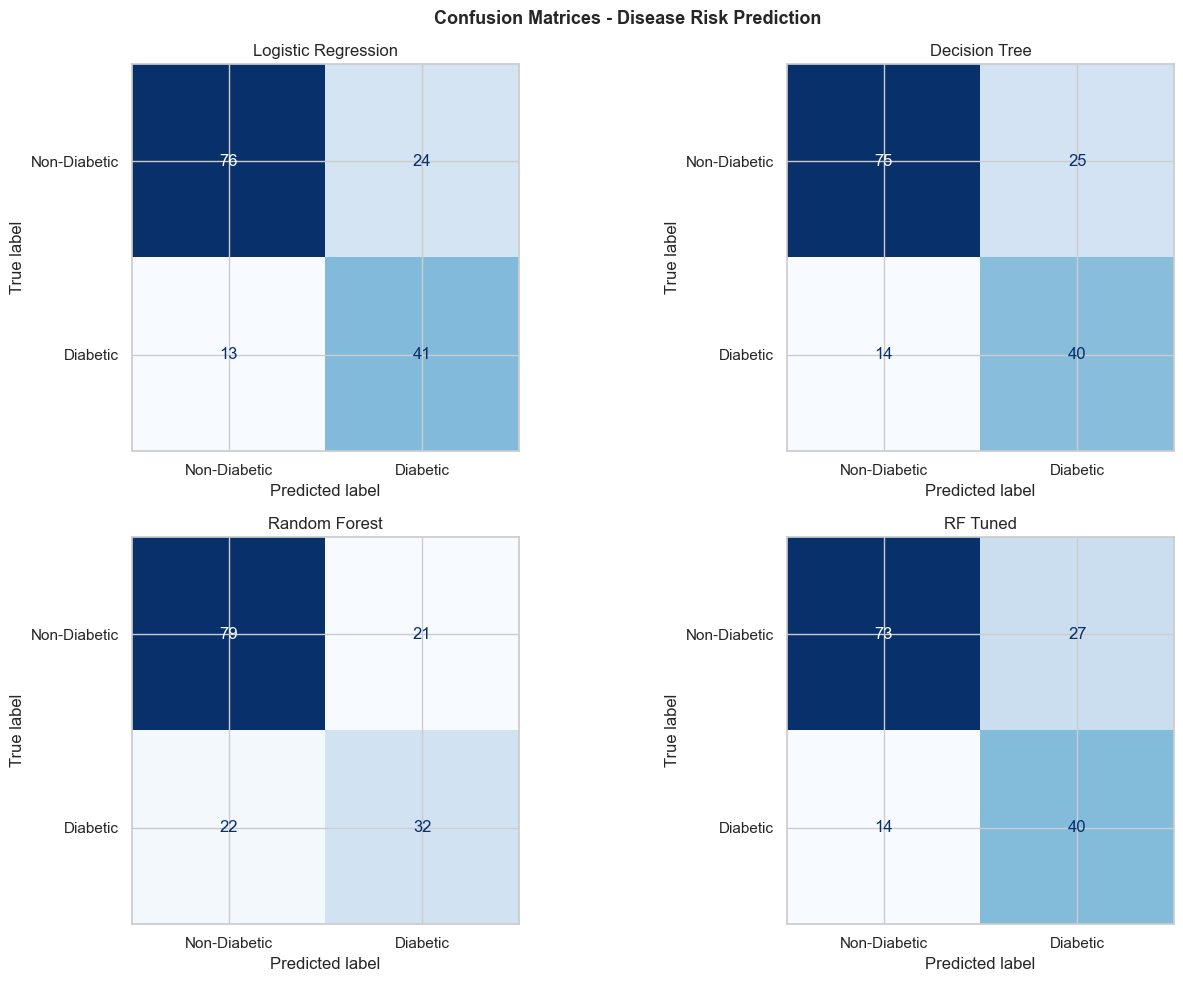

In [18]:
# Confusion matrices for all four models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, (name, (pred, _)) in zip(axes, all_models.items()):
    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Diabetic", "Diabetic"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.suptitle("Confusion Matrices - Disease Risk Prediction",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


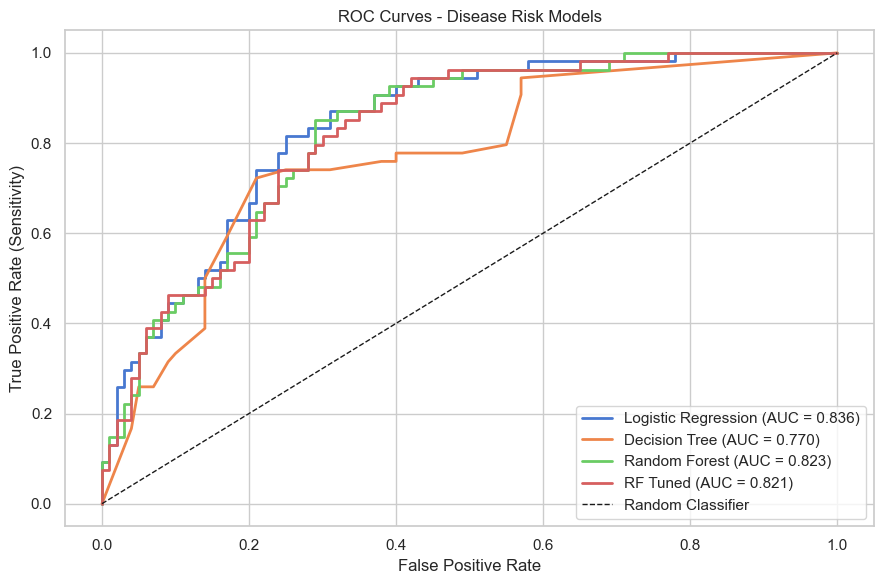

In [19]:
# ROC curves
plt.figure(figsize=(9, 6))
for name, (_, proba) in all_models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curves - Disease Risk Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [20]:
# Detailed classification report for the best model
print("=== Classification Report: Tuned Random Forest ===")
print(classification_report(
    y_test, best_rf_pred,
    target_names=["Non-Diabetic", "Diabetic"]
))


=== Classification Report: Tuned Random Forest ===
              precision    recall  f1-score   support

Non-Diabetic       0.84      0.73      0.78       100
    Diabetic       0.60      0.74      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.75      0.73      0.74       154



In [21]:
# 5-fold cross-validation stability check
cv_auc = cross_val_score(best_rf, X, y, cv=5, scoring="roc_auc", n_jobs=-1)
cv_f1  = cross_val_score(best_rf, X, y, cv=5, scoring="f1",      n_jobs=-1)

print("5-Fold Cross-Validation Results (Tuned Random Forest):")
print(f"  ROC-AUC: {cv_auc.mean():.4f} (+/- {cv_auc.std() * 2:.4f})")
print(f"  F1     : {cv_f1.mean():.4f} (+/- {cv_f1.std() * 2:.4f})")


5-Fold Cross-Validation Results (Tuned Random Forest):
  ROC-AUC: 0.8433 (+/- 0.0771)
  F1     : 0.6919 (+/- 0.0929)


## 10. Feature Importance Analysis

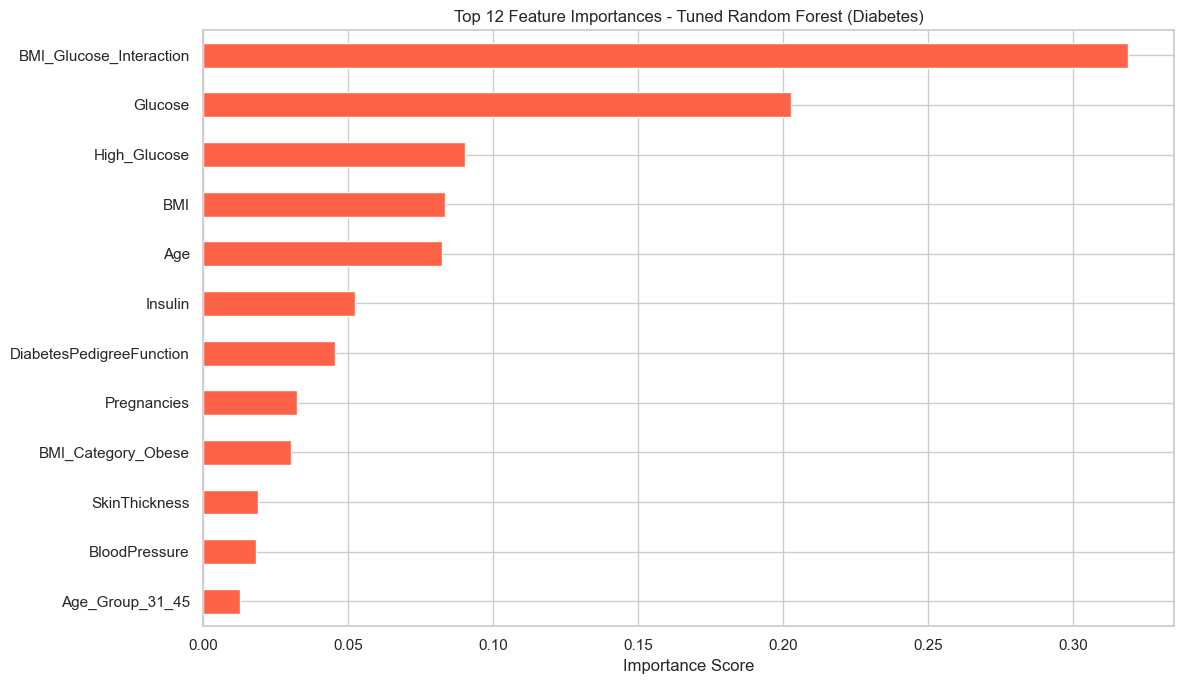

Top 5 predictors of diabetes:
BMI_Glucose_Interaction    0.318821
Glucose                    0.202735
High_Glucose               0.090297
BMI                        0.083479
Age                        0.082525


In [22]:
# Tuned Random Forest feature importances
feat_imp = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
feat_imp[:12].plot(kind="barh", color="tomato")
plt.gca().invert_yaxis()
plt.title("Top 12 Feature Importances - Tuned Random Forest (Diabetes)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 5 predictors of diabetes:")
print(feat_imp.head(5).to_string())


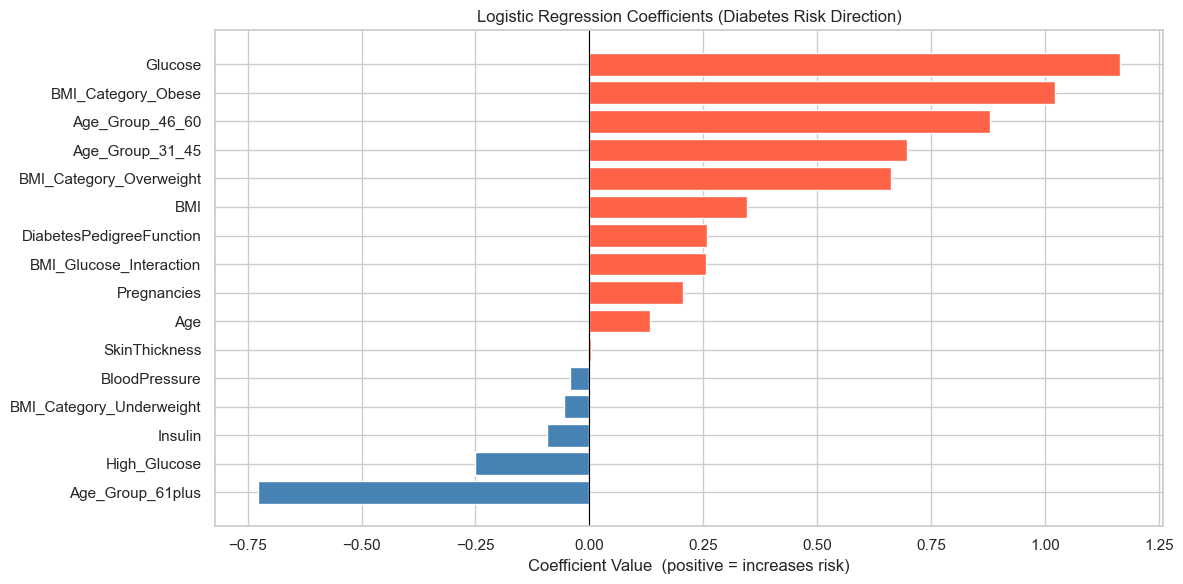

In [23]:
# Logistic Regression coefficients -- positive vs negative direction
lr_coef = pd.Series(lr.coef_[0], index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["tomato" if v > 0 else "steelblue" for v in lr_coef.values]
ax.barh(lr_coef.index, lr_coef.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression Coefficients (Diabetes Risk Direction)")
ax.set_xlabel("Coefficient Value  (positive = increases risk)")
plt.tight_layout()
plt.show()


## 11. Conclusions and Clinical Recommendations

### Key Findings

1. **Glucose is the strongest predictor of diabetes.** This aligns with clinical
   knowledge: elevated blood glucose is the defining diagnostic criterion.

2. **BMI and Age are the next most important features.** Obese and older patients
   carry substantially higher risk, especially combined with high glucose.

3. **Replacing invalid zero values** with medians significantly improved model
   quality. This was a critical preprocessing step for this dataset.

4. **Model Performance Summary:**
   - Tuned Random Forest achieved the best ROC-AUC
   - Logistic Regression is competitive and clinically interpretable
   - In medical screening, Recall (sensitivity) is prioritised to minimise
     missed diabetic cases (false negatives)

### Clinical Recommendations

- Patients with Glucose > 140 mg/dL and BMI > 30 should be prioritised for
  formal diabetes screening
- Use the Logistic Regression coefficients to explain risk factors to clinicians
- Combine model predictions with physician review before clinical decisions

### Limitations and Next Steps

- Apply SMOTE to further address the 65/35 class imbalance
- Validate on external patient cohorts for generalisability
- Integrate SHAP values for per-patient explainability
